In [24]:
import pandas as pd

df = pd.read_csv('/content/flight_data_2024_sample.csv')

df.head()

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,4,18,4,2024-04-18,MQ,3535.00,DFW,"Dallas/Fort Worth, TX",Texas,...,0,151.00,144.00,119.00,835.00,0,0,0,0,0
1,2024,1,1,1,2024-01-01,AA,148.00,CLT,"Charlotte, NC",North Carolina,...,0,286.00,273.00,253.00,1773.00,0,0,0,0,0
2,2024,12,12,4,2024-12-12,9E,5440.00,CHA,"Chattanooga, TN",Tennessee,...,0,59.00,50.00,29.00,106.00,0,0,0,0,0
3,2024,4,8,1,2024-04-08,WN,1971.00,OMA,"Omaha, NE",Nebraska,...,0,180.00,177.00,163.00,1099.00,0,0,0,0,0
4,2024,2,16,5,2024-02-16,WN,862.00,BWI,"Baltimore, MD",Maryland,...,0,90.00,96.00,76.00,399.00,0,0,0,0,0


In [25]:
df.shape

(10000, 35)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 10000 non-null  int64  
 1   month                10000 non-null  int64  
 2   day_of_month         10000 non-null  int64  
 3   day_of_week          10000 non-null  int64  
 4   fl_date              10000 non-null  object 
 5   op_unique_carrier    10000 non-null  object 
 6   op_carrier_fl_num    10000 non-null  float64
 7   origin               10000 non-null  object 
 8   origin_city_name     10000 non-null  object 
 9   origin_state_nm      10000 non-null  object 
 10  dest                 10000 non-null  object 
 11  dest_city_name       10000 non-null  object 
 12  dest_state_nm        10000 non-null  object 
 13  crs_dep_time         10000 non-null  int64  
 14  dep_time             9884 non-null   float64
 15  dep_delay            9884 non-null   

In [27]:
df.isnull().sum()

,0
year,0
month,0
day_of_month,0
day_of_week,0
fl_date,0
op_unique_carrier,0
op_carrier_fl_num,0
origin,0
origin_city_name,0
origin_state_nm,0


In [28]:
nulos = df.isnull().sum()
percentual_nulos = (nulos / len(df)) * 100

resumo_nulos = pd.DataFrame({
    'valores_nulos': nulos,
    'percentual': percentual_nulos
})

resumo_nulos[resumo_nulos['valores_nulos'] > 0].sort_values(by='percentual', ascending=False)

,valores_nulos,percentual
cancellation_code,9878,98.78
air_time,164,1.64
arr_delay,164,1.64
actual_elapsed_time,164,1.64
taxi_in,127,1.27
wheels_on,127,1.27
arr_time,127,1.27
taxi_out,120,1.20
wheels_off,120,1.20
dep_delay,116,1.16


In [29]:
pd.set_option('display.float_format', '{:.2f}'.format)

In [30]:
df.describe()

,year,month,day_of_month,day_of_week,op_carrier_fl_num,crs_dep_time,dep_time,dep_delay,taxi_out,wheels_off,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,9884.00,9884.00,9880.00,9880.00,...,10000.00,10000.00,9836.00,9836.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,2024.00,6.61,15.84,3.95,2529.76,1324.45,1330.16,13.00,17.88,1353.56,...,0.00,147.37,141.73,115.45,838.35,4.87,1.08,3.03,0.01,6.14
std,0.00,3.38,8.79,2.01,1656.00,488.54,504.95,53.61,9.77,507.45,...,0.06,72.93,72.79,70.74,598.53,33.50,15.82,15.76,0.38,29.63
min,2024.00,1.00,1.00,1.00,1.00,22.00,1.00,-22.00,4.00,1.00,...,0.00,23.00,17.00,8.00,31.00,0.00,0.00,0.00,0.00,0.00
25%,2024.00,4.00,8.00,2.00,1172.00,905.00,910.00,-6.00,12.00,928.75,...,0.00,93.00,89.00,64.00,404.00,0.00,0.00,0.00,0.00,0.00
50%,2024.00,7.00,16.00,4.00,2254.00,1320.00,1324.00,-2.00,15.00,1337.00,...,0.00,130.00,125.00,98.00,680.00,0.00,0.00,0.00,0.00,0.00
75%,2024.00,10.00,23.00,6.00,3742.00,1734.25,1745.00,9.25,21.00,1759.00,...,0.00,179.00,174.00,145.00,1072.00,0.00,0.00,0.00,0.00,0.00
max,2024.00,12.00,31.00,7.00,8771.00,2359.00,2400.00,2011.00,154.00,2400.00,...,1.00,685.00,691.00,635.00,5095.00,2011.00,664.00,454.00,22.00,995.00


In [31]:
df['dep_delay'].describe()

,dep_delay
count,9884.00
mean,13.00
std,53.61
min,-22.00
25%,-6.00
50%,-2.00
75%,9.25
max,2011.00


In [32]:
df.sort_values(by='dep_delay', ascending=False).head(10)

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
9506,2024,6,17,1,2024-06-17,AA,949.00,SDF,"Louisville, KY",Kentucky,...,0,158.00,161.00,118.00,910.00,2011,0,3,0,0
972,2024,12,4,3,2024-12-04,OO,5502.00,ICT,"Wichita, KS",Kansas,...,0,120.00,110.00,85.00,542.00,0,0,0,0,995
7795,2024,4,20,6,2024-04-20,AA,2133.00,EWR,"Newark, NJ",New Jersey,...,0,337.00,395.00,350.00,2133.00,10,0,58,0,907
9107,2024,3,2,6,2024-03-02,AA,2302.00,PSP,"Palm Springs, CA",California,...,0,75.00,62.00,46.00,261.00,0,595,0,0,243
1048,2024,7,5,5,2024-07-05,AA,267.00,BOS,"Boston, MA",Massachusetts,...,0,94.00,83.00,58.00,280.00,601,0,0,0,141
4180,2024,7,21,7,2024-07-21,AA,1669.00,DFW,"Dallas/Fort Worth, TX",Texas,...,0,187.00,180.00,154.00,1235.00,733,0,0,0,0
3462,2024,11,7,4,2024-11-07,OO,5678.00,MOT,"Minot, ND",North Dakota,...,0,146.00,114.00,90.00,604.00,662,0,0,0,0
4019,2024,7,21,7,2024-07-21,OO,5670.00,SFO,"San Francisco, CA",California,...,0,59.00,55.00,29.00,77.00,0,664,0,0,0
3051,2024,1,26,5,2024-01-26,9E,5393.00,LGA,"New York, NY",New York,...,0,82.00,66.00,45.00,258.00,0,637,0,0,0
7603,2024,5,23,4,2024-05-23,B6,82.00,IAH,"Houston, TX",Texas,...,0,217.00,209.00,185.00,1417.00,411,0,0,0,230


In [33]:
df.sort_values(by='dep_delay', ascending=False)[[
    'fl_date',
    'op_unique_carrier',
    'origin',
    'dest',
    'dep_delay',
    'arr_delay',
    'carrier_delay',
    'weather_delay',
    'nas_delay',
    'security_delay',
    'late_aircraft_delay',
    'cancelled',
    'diverted'
]].head(10)

,fl_date,op_unique_carrier,origin,dest,dep_delay,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,cancelled,diverted
9506,2024-06-17,AA,SDF,MIA,2011.00,2014.00,2011,0,3,0,0,0,0
972,2024-12-04,OO,ICT,IAH,1005.00,995.00,0,0,0,0,995,0,0
7795,2024-04-20,AA,EWR,PHX,917.00,975.00,10,0,58,0,907,0,0
9107,2024-03-02,AA,PSP,PHX,851.00,838.00,0,595,0,0,243,0,0
1048,2024-07-05,AA,BOS,PHL,753.00,742.00,601,0,0,0,141,0,0
4180,2024-07-21,AA,DFW,LAX,740.00,733.00,733,0,0,0,0,0,0
3462,2024-11-07,OO,MOT,DEN,694.00,662.00,662,0,0,0,0,0,0
4019,2024-07-21,OO,SFO,MRY,668.00,664.00,0,664,0,0,0,0,0
3051,2024-01-26,9E,LGA,BTV,653.00,637.00,0,637,0,0,0,0,0
7603,2024-05-23,B6,IAH,JFK,649.00,641.00,411,0,0,0,230,0,0


In [34]:
df.shape

(10000, 35)

In [35]:
df['dep_delay'].describe()

,dep_delay
count,9884.00
mean,13.00
std,53.61
min,-22.00
25%,-6.00
50%,-2.00
75%,9.25
max,2011.00


In [36]:
df['arr_delay'].describe()

,arr_delay
count,9836.00
mean,7.55
std,55.80
min,-78.00
25%,-15.00
50%,-6.00
75%,10.00
max,2014.00


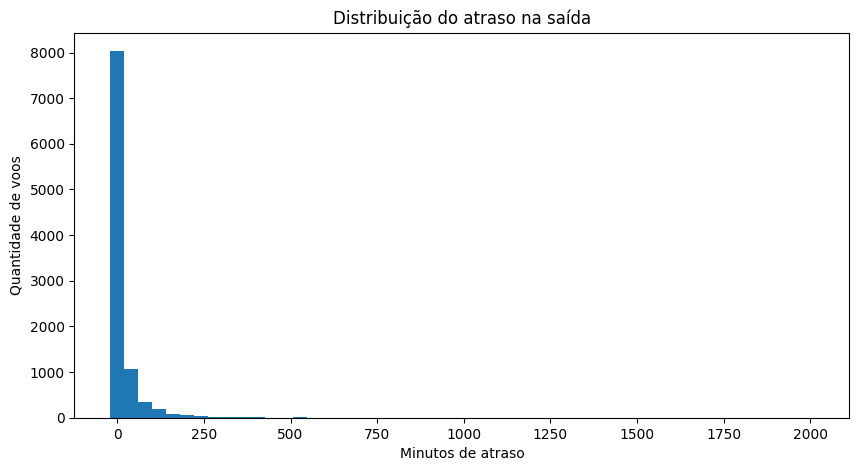

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df['dep_delay'].dropna(), bins=50)
plt.title('Distribuição do atraso na saída')
plt.xlabel('Minutos de atraso')
plt.ylabel('Quantidade de voos')
plt.show()

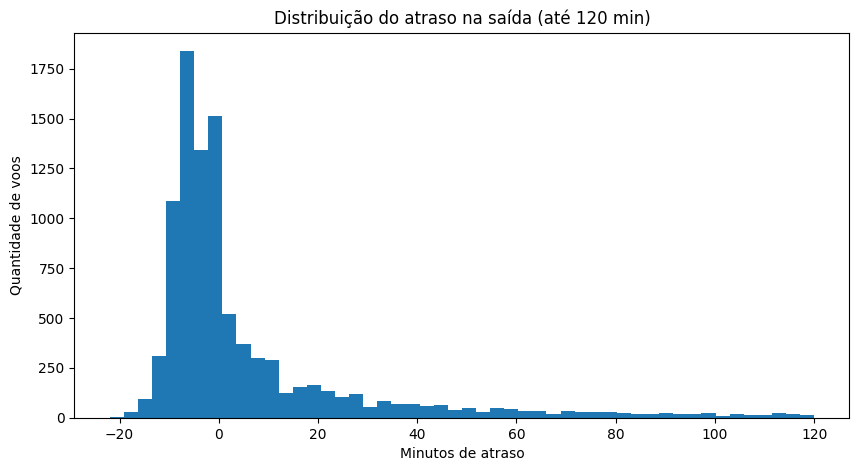

In [38]:
plt.figure(figsize=(10,5))
plt.hist(df[df['dep_delay'] <= 120]['dep_delay'].dropna(), bins=50)
plt.title('Distribuição do atraso na saída (até 120 min)')
plt.xlabel('Minutos de atraso')
plt.ylabel('Quantidade de voos')
plt.show()

In [39]:
top_carriers = (
    df.groupby('op_unique_carrier')['dep_delay']
    .mean()
    .sort_values(ascending=False)
)

top_carriers

,dep_delay
op_unique_carrier,
AA,21.99
F9,18.86
B6,17.59
OH,16.68
NK,13.86
OO,12.92
G4,12.84
UA,12.73
WN,12.16


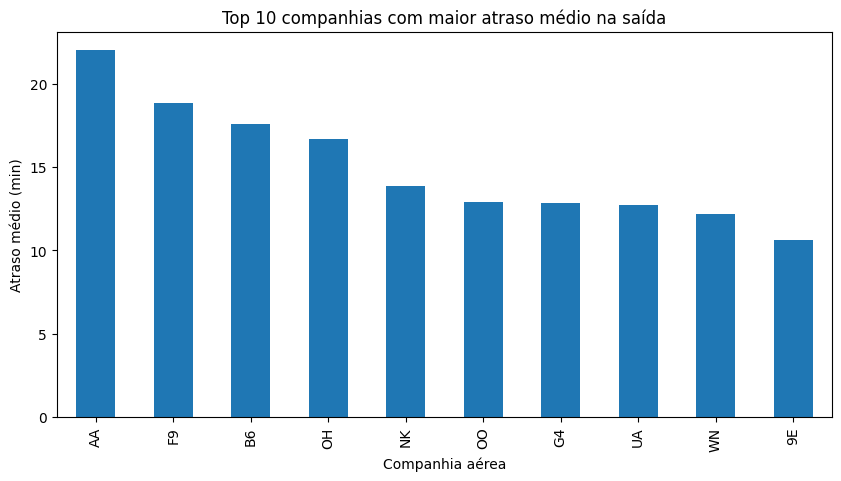

In [40]:
top_carriers.head(10).plot(kind='bar', figsize=(10,5))
plt.title('Top 10 companhias com maior atraso médio na saída')
plt.xlabel('Companhia aérea')
plt.ylabel('Atraso médio (min)')
plt.show()

In [41]:
df.groupby('op_unique_carrier')['dep_delay'].agg(['count', 'mean', 'median']).sort_values(by='mean', ascending=False)

,count,mean,median
op_unique_carrier,,,
AA,1364,21.99,-1.00
F9,288,18.86,-3.00
B6,330,17.59,-2.00
OH,317,16.68,-3.00
NK,351,13.86,-2.00
OO,1072,12.92,-4.00
G4,170,12.84,-4.00
UA,1022,12.73,-2.00
WN,2002,12.16,0.00


In [42]:
df.groupby('origin')['dep_delay'].agg(['count', 'mean', 'median']).sort_values(by='mean', ascending=False).head(15)

,count,mean,median
origin,,,
VCT,2,153.50,153.50
ADQ,1,116.00,116.00
MOT,6,111.83,-6.00
FLG,2,108.50,108.50
YUM,4,103.25,-6.00
SCK,1,100.00,100.00
MBS,6,97.67,-3.00
PSE,3,91.67,135.00
CRW,9,83.33,0.00


In [43]:
aeroportos_filtrados = (
    df.groupby('origin')['dep_delay']
    .agg(['count', 'mean', 'median'])
)

aeroportos_filtrados = aeroportos_filtrados[aeroportos_filtrados['count'] >= 30]
aeroportos_filtrados.sort_values(by='mean', ascending=False).head(15)

,count,mean,median
origin,,,
SDF,38,72.45,-3.50
PIT,69,30.57,0.00
SNA,49,23.10,-3.00
SJU,55,21.13,-2.00
CLT,314,20.56,-1.00
BHM,32,20.38,-2.50
OKC,41,20.02,-4.00
IAD,68,19.91,-0.50
MIA,161,19.71,0.00


In [44]:
df.groupby('month')['dep_delay'].agg(['count', 'mean', 'median']).sort_index()

,count,mean,median
month,,,
1,726,15.01,-2.00
2,711,7.31,-2.00
3,832,13.31,-2.00
4,851,11.60,-2.00
5,824,16.93,-1.00
6,831,17.33,-1.00
7,890,25.73,0.00
8,860,15.27,-2.00
9,831,6.36,-3.00


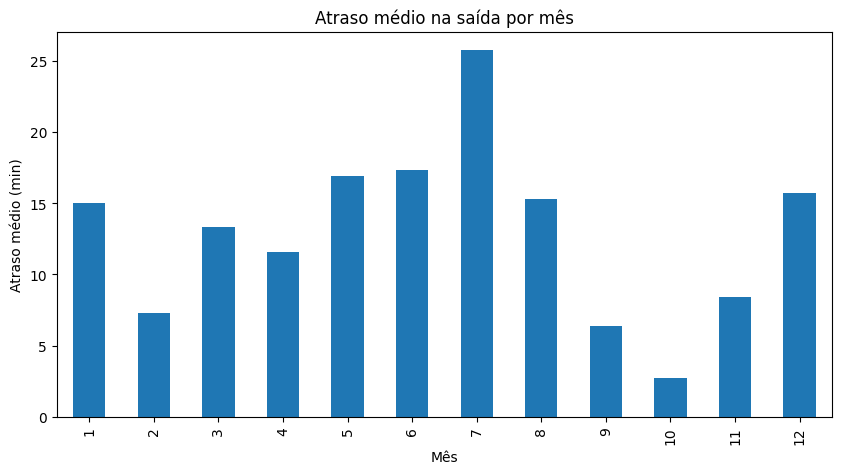

In [45]:
atraso_mes = df.groupby('month')['dep_delay'].mean()

atraso_mes.plot(kind='bar', figsize=(10,5))
plt.title('Atraso médio na saída por mês')
plt.xlabel('Mês')
plt.ylabel('Atraso médio (min)')
plt.show()

In [46]:
df.groupby('month')['dep_delay'].agg(['mean', 'median']).sort_index()

,mean,median
month,,
1,15.01,-2.00
2,7.31,-2.00
3,13.31,-2.00
4,11.60,-2.00
5,16.93,-1.00
6,17.33,-1.00
7,25.73,0.00
8,15.27,-2.00
9,6.36,-3.00


In [47]:
df.groupby('day_of_week')['dep_delay'].agg(['count', 'mean', 'median']).sort_index()

,count,mean,median
day_of_week,,,
1,1537,12.32,-2.00
2,1386,9.90,-3.00
3,1304,9.90,-2.00
4,1530,13.25,-2.00
5,1442,14.91,-2.00
6,1287,15.84,-2.00
7,1398,14.87,-2.00


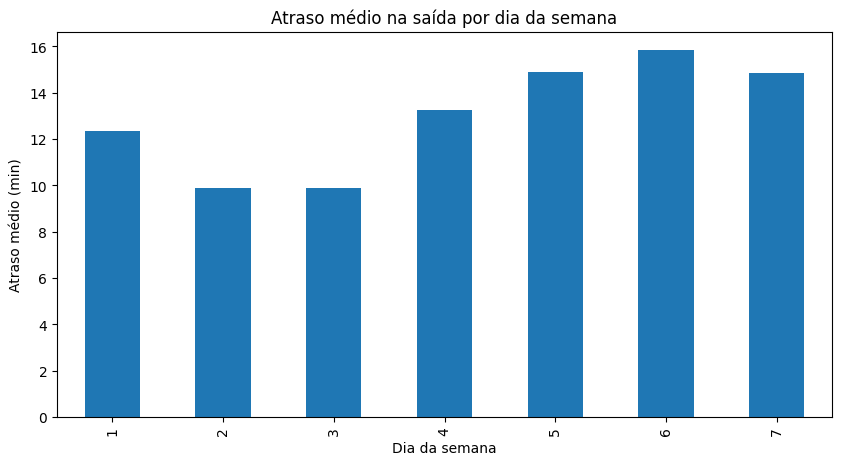

In [48]:
atraso_dia_semana = df.groupby('day_of_week')['dep_delay'].mean()

atraso_dia_semana.plot(kind='bar', figsize=(10,5))
plt.title('Atraso médio na saída por dia da semana')
plt.xlabel('Dia da semana')
plt.ylabel('Atraso médio (min)')
plt.show()

In [49]:
df['hora_saida_prevista'] = (df['crs_dep_time'] // 100).astype(int)

df.groupby('hora_saida_prevista')['dep_delay'].agg(['count', 'mean', 'median']).sort_index()

,count,mean,median
hora_saida_prevista,,,
0,13,10.62,12.00
1,7,3.57,-2.00
2,2,0.00,0.00
3,3,-12.67,-18.00
4,1,51.00,51.00
5,279,5.51,-4.00
6,683,8.61,-4.00
7,694,10.01,-3.00
8,671,4.59,-3.00


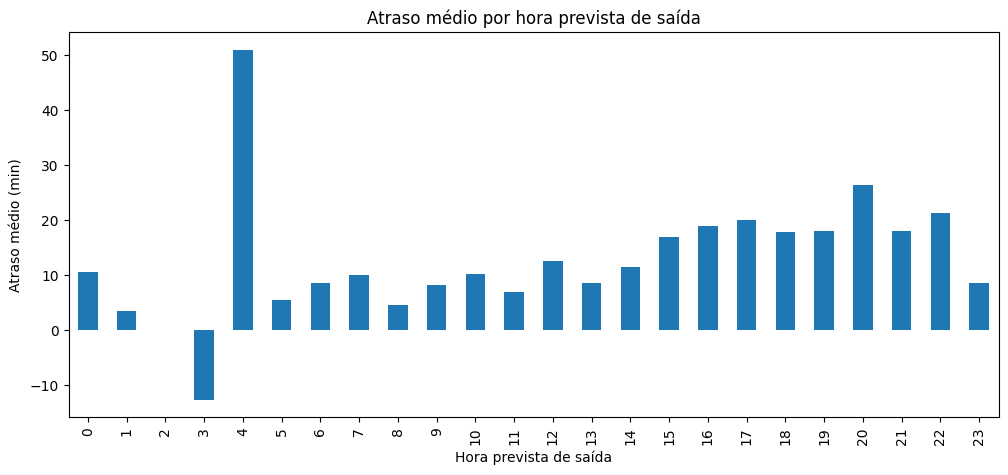

In [50]:
atraso_hora = df.groupby('hora_saida_prevista')['dep_delay'].mean()

atraso_hora.plot(kind='bar', figsize=(12,5))
plt.title('Atraso médio por hora prevista de saída')
plt.xlabel('Hora prevista de saída')
plt.ylabel('Atraso médio (min)')
plt.show()

In [51]:
df.groupby('hora_saida_prevista')['dep_delay'].agg(['count', 'mean', 'median']).sort_index()

,count,mean,median
hora_saida_prevista,,,
0,13,10.62,12.00
1,7,3.57,-2.00
2,2,0.00,0.00
3,3,-12.67,-18.00
4,1,51.00,51.00
5,279,5.51,-4.00
6,683,8.61,-4.00
7,694,10.01,-3.00
8,671,4.59,-3.00


In [52]:
df_modelo = df.copy()

df_modelo = df_modelo.dropna(subset=['dep_delay'])

df_modelo['atraso_15min'] = (df_modelo['dep_delay'] > 15).astype(int)

df_modelo['atraso_15min'].value_counts(normalize=True) * 100

,proportion
atraso_15min,
0,79.68
1,20.32


In [53]:
colunas_modelo = [
    'month',
    'day_of_month',
    'day_of_week',
    'op_unique_carrier',
    'origin',
    'dest',
    'crs_dep_time',
    'crs_arr_time',
    'distance',
    'atraso_15min'
]

df_modelo = df_modelo[colunas_modelo].copy()

df_modelo.head()

,month,day_of_month,day_of_week,op_unique_carrier,origin,dest,crs_dep_time,crs_arr_time,distance,atraso_15min
0,4,18,4,MQ,DFW,RAP,1018,1149,835.00,0
1,1,1,1,AA,CLT,PHX,1637,1923,1773.00,0
2,12,12,4,9E,CHA,ATL,1000,1059,106.00,0
3,4,8,1,WN,OMA,LAS,1330,1430,1099.00,0
4,2,16,5,WN,BWI,MYR,1340,1510,399.00,0


In [54]:
X = df_modelo.drop('atraso_15min', axis=1)
y = df_modelo['atraso_15min']

X = pd.get_dummies(X, columns=['op_unique_carrier', 'origin', 'dest'], drop_first=True)

X.shape

(9884, 589)

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

modelo_log = LogisticRegression(max_iter=1000)
modelo_log.fit(X_train, y_train)

y_pred = modelo_log.predict(X_test)

print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nMatriz de confusão:")
print(confusion_matrix(y_test, y_pred))
print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred))

Acurácia: 0.7936267071320182

Matriz de confusão:
[[1567    8]
 [ 400    2]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.80      0.99      0.88      1575
           1       0.20      0.00      0.01       402

    accuracy                           0.79      1977
   macro avg       0.50      0.50      0.45      1977
weighted avg       0.68      0.79      0.71      1977



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [56]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# padronizar os dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# modelo com balanceamento de classe
modelo_log_bal = LogisticRegression(max_iter=2000, class_weight='balanced')

modelo_log_bal.fit(X_train_scaled, y_train)

y_pred_bal = modelo_log_bal.predict(X_test_scaled)

print("Acurácia:", accuracy_score(y_test, y_pred_bal))
print("\nMatriz de confusão:")
print(confusion_matrix(y_test, y_pred_bal))
print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred_bal))

Acurácia: 0.5973697521497218

Matriz de confusão:
[[950 625]
 [171 231]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.85      0.60      0.70      1575
           1       0.27      0.57      0.37       402

    accuracy                           0.60      1977
   macro avg       0.56      0.59      0.54      1977
weighted avg       0.73      0.60      0.64      1977



In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

modelo_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)

print("Acurácia:", accuracy_score(y_test, y_pred_rf))
print("\nMatriz de confusão:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred_rf))

Acurácia: 0.7956499747091553

Matriz de confusão:
[[1557   18]
 [ 386   16]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.80      0.99      0.89      1575
           1       0.47      0.04      0.07       402

    accuracy                           0.80      1977
   macro avg       0.64      0.51      0.48      1977
weighted avg       0.73      0.80      0.72      1977



In [58]:
!pip install xgboost

In [59]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

modelo_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=4,
    random_state=42,
    eval_metric='logloss'
)

modelo_xgb.fit(X_train, y_train)

y_pred_xgb = modelo_xgb.predict(X_test)

print("Acurácia:", accuracy_score(y_test, y_pred_xgb))
print("\nMatriz de confusão:")
print(confusion_matrix(y_test, y_pred_xgb))
print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred_xgb))

Acurácia: 0.642893272635306

Matriz de confusão:
[[1021  554]
 [ 152  250]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.87      0.65      0.74      1575
           1       0.31      0.62      0.41       402

    accuracy                           0.64      1977
   macro avg       0.59      0.64      0.58      1977
weighted avg       0.76      0.64      0.68      1977



In [60]:
import pandas as pd

importancias = pd.DataFrame({
    'variavel': X.columns,
    'importancia': modelo_xgb.feature_importances_
})

importancias = importancias.sort_values(by='importancia', ascending=False)

importancias.head(20)

,variavel,importancia
3,crs_dep_time,0.01
19,op_unique_carrier_YX,0.01
16,op_unique_carrier_OO,0.01
18,op_unique_carrier_WN,0.01
6,op_unique_carrier_AA,0.01
62,origin_BWI,0.01
397,dest_FLL,0.01
0,month,0.01
358,dest_CLE,0.01
320,dest_AUS,0.01


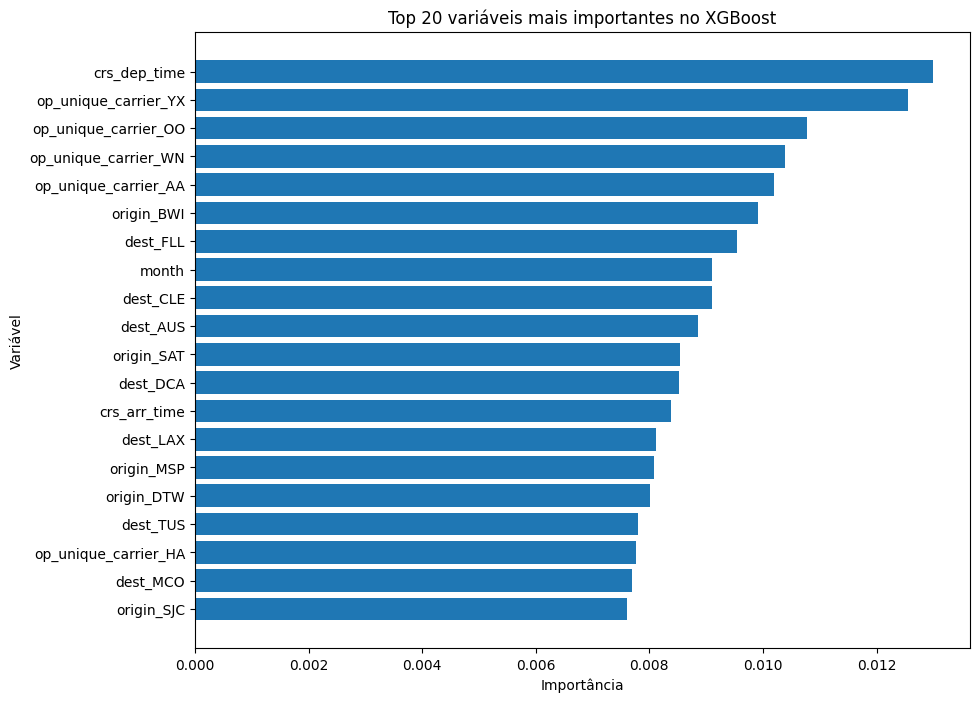

In [61]:
import matplotlib.pyplot as plt

top20 = importancias.head(20).sort_values(by='importancia')

plt.figure(figsize=(10,8))
plt.barh(top20['variavel'], top20['importancia'])
plt.title('Top 20 variáveis mais importantes no XGBoost')
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.show()

In [62]:
y_proba_xgb = modelo_xgb.predict_proba(X_test)[:, 1]

for limite in [0.50, 0.40, 0.35, 0.30]:
    y_pred_limite = (y_proba_xgb >= limite).astype(int)

    print(f"\n--- Limite: {limite} ---")
    print(confusion_matrix(y_test, y_pred_limite))
    print(classification_report(y_test, y_pred_limite))


--- Limite: 0.5 ---
[[1021  554]
 [ 152  250]]
              precision    recall  f1-score   support

           0       0.87      0.65      0.74      1575
           1       0.31      0.62      0.41       402

    accuracy                           0.64      1977
   macro avg       0.59      0.64      0.58      1977
weighted avg       0.76      0.64      0.68      1977


--- Limite: 0.4 ---
[[666 909]
 [ 75 327]]
              precision    recall  f1-score   support

           0       0.90      0.42      0.58      1575
           1       0.26      0.81      0.40       402

    accuracy                           0.50      1977
   macro avg       0.58      0.62      0.49      1977
weighted avg       0.77      0.50      0.54      1977


--- Limite: 0.35 ---
[[ 460 1115]
 [  54  348]]
              precision    recall  f1-score   support

           0       0.89      0.29      0.44      1575
           1       0.24      0.87      0.37       402

    accuracy                           0.

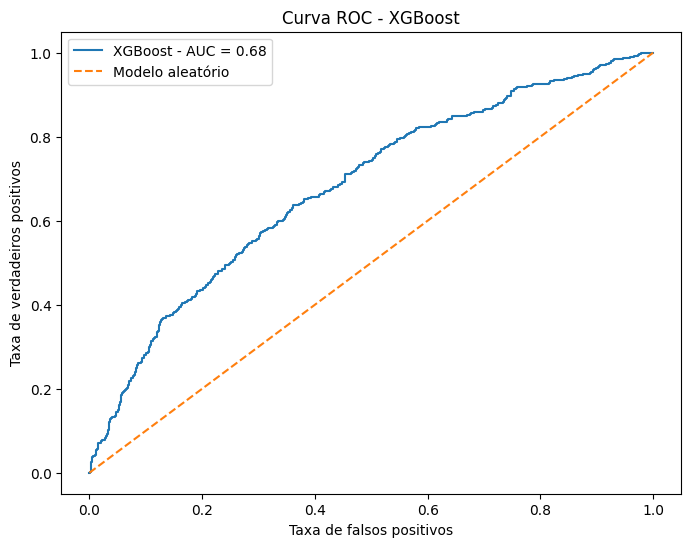

AUC: 0.6804722419647793


In [63]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_proba_xgb = modelo_xgb.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba_xgb)
auc = roc_auc_score(y_test, y_proba_xgb)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'XGBoost - AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', label='Modelo aleatório')
plt.title('Curva ROC - XGBoost')
plt.xlabel('Taxa de falsos positivos')
plt.ylabel('Taxa de verdadeiros positivos')
plt.legend()
plt.show()

print("AUC:", auc)

In [64]:
resultado_modelo = X_test.copy()

resultado_modelo['real_atraso_15min'] = y_test.values
resultado_modelo['probabilidade_atraso'] = y_proba_xgb
resultado_modelo['previsao_atraso_050'] = (y_proba_xgb >= 0.50).astype(int)

resultado_modelo.to_csv('resultado_modelo_xgboost.csv', index=False)

In [65]:
comparacao_limiares = pd.DataFrame({
    'limiar': [0.50, 0.40, 0.35],
    'recall_classe_1': [0.62, 0.81, 0.87],
    'precision_classe_1': [0.31, 0.26, 0.24],
    'acuracia': [0.64, 0.50, 0.41],
    'leitura': [
        'Melhor equilíbrio geral',
        'Mais sensível para detectar atrasos',
        'Recall alto, mas muitos falsos positivos'
    ]
})

comparacao_limiares.to_csv('comparacao_limiares_xgboost.csv', index=False)

In [66]:
import os
os.listdir()

['.config',
 'resultado_modelo_xgboost.csv',
 'flight_data_2024_sample.csv',
 'comparacao_limiares_xgboost.csv',
 'sample_data']

# Predição de atraso de voos com Machine Learning

Este projeto tem como objetivo prever se um voo terá atraso superior a 15 minutos na saída, utilizando informações operacionais conhecidas antes da decolagem.

A variável-alvo utilizada foi `atraso_15min`, em que 0 representa voos sem atraso relevante e 1 representa voos com atraso superior a 15 minutos.

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_curve,
    roc_auc_score
)

from xgboost import XGBClassifier

In [68]:
df = pd.read_csv('/content/flight_data_2024_sample.csv')

df.head()

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,4,18,4,2024-04-18,MQ,3535.00,DFW,"Dallas/Fort Worth, TX",Texas,...,0,151.00,144.00,119.00,835.00,0,0,0,0,0
1,2024,1,1,1,2024-01-01,AA,148.00,CLT,"Charlotte, NC",North Carolina,...,0,286.00,273.00,253.00,1773.00,0,0,0,0,0
2,2024,12,12,4,2024-12-12,9E,5440.00,CHA,"Chattanooga, TN",Tennessee,...,0,59.00,50.00,29.00,106.00,0,0,0,0,0
3,2024,4,8,1,2024-04-08,WN,1971.00,OMA,"Omaha, NE",Nebraska,...,0,180.00,177.00,163.00,1099.00,0,0,0,0,0
4,2024,2,16,5,2024-02-16,WN,862.00,BWI,"Baltimore, MD",Maryland,...,0,90.00,96.00,76.00,399.00,0,0,0,0,0


## Entendimento inicial da base

In [69]:
df.shape

(10000, 35)

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 10000 non-null  int64  
 1   month                10000 non-null  int64  
 2   day_of_month         10000 non-null  int64  
 3   day_of_week          10000 non-null  int64  
 4   fl_date              10000 non-null  object 
 5   op_unique_carrier    10000 non-null  object 
 6   op_carrier_fl_num    10000 non-null  float64
 7   origin               10000 non-null  object 
 8   origin_city_name     10000 non-null  object 
 9   origin_state_nm      10000 non-null  object 
 10  dest                 10000 non-null  object 
 11  dest_city_name       10000 non-null  object 
 12  dest_state_nm        10000 non-null  object 
 13  crs_dep_time         10000 non-null  int64  
 14  dep_time             9884 non-null   float64
 15  dep_delay            9884 non-null   

In [71]:
df.isnull().sum()

,0
year,0
month,0
day_of_month,0
day_of_week,0
fl_date,0
op_unique_carrier,0
op_carrier_fl_num,0
origin,0
origin_city_name,0
origin_state_nm,0


## Análise de valores nulos

Nesta etapa, verifiquei quais colunas possuem valores ausentes e qual o percentual de impacto na base.

In [72]:
nulos = df.isnull().sum()
percentual_nulos = (nulos / len(df)) * 100

resumo_nulos = pd.DataFrame({
    'valores_nulos': nulos,
    'percentual': percentual_nulos
})

resumo_nulos[resumo_nulos['valores_nulos'] > 0].sort_values(
    by='percentual',
    ascending=False
)

,valores_nulos,percentual
cancellation_code,9878,98.78
air_time,164,1.64
arr_delay,164,1.64
actual_elapsed_time,164,1.64
taxi_in,127,1.27
wheels_on,127,1.27
arr_time,127,1.27
taxi_out,120,1.20
wheels_off,120,1.20
dep_delay,116,1.16


## Distribuição dos atrasos de saída

Antes da modelagem, é importante entender como os atrasos se comportam na base. Nesta etapa, eu fiz a analise e a distribuição da variável `dep_delay`.

In [73]:
df['dep_delay'].describe()

,dep_delay
count,9884.00
mean,13.00
std,53.61
min,-22.00
25%,-6.00
50%,-2.00
75%,9.25
max,2011.00


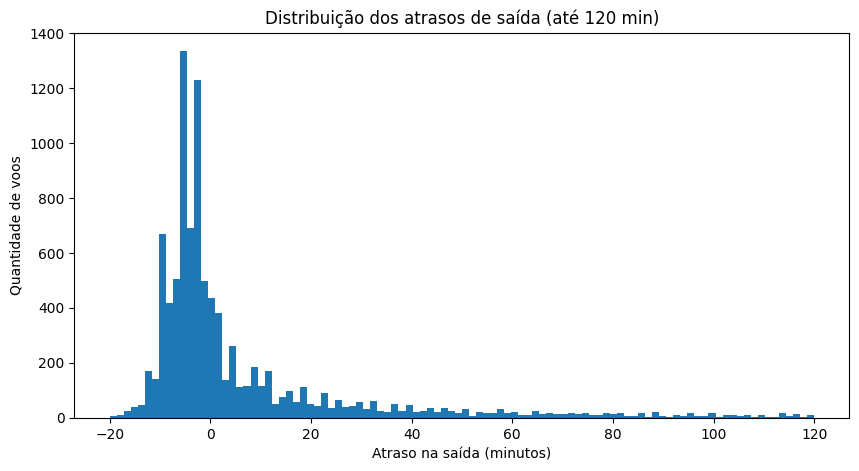

In [74]:
plt.figure(figsize=(10,5))
plt.hist(df['dep_delay'].dropna(), bins=100, range=(-20, 120))
plt.title('Distribuição dos atrasos de saída (até 120 min)')
plt.xlabel('Atraso na saída (minutos)')
plt.ylabel('Quantidade de voos')
plt.show()

## Atraso médio por mês

Nesta etapa, analisei o atraso médio de saída por mês para observar possíveis padrões sazonais.

In [75]:
atraso_mes = df.groupby('month')['dep_delay'].agg(['count', 'mean', 'median']).sort_index()

atraso_mes

,count,mean,median
month,,,
1,726,15.01,-2.00
2,711,7.31,-2.00
3,832,13.31,-2.00
4,851,11.60,-2.00
5,824,16.93,-1.00
6,831,17.33,-1.00
7,890,25.73,0.00
8,860,15.27,-2.00
9,831,6.36,-3.00


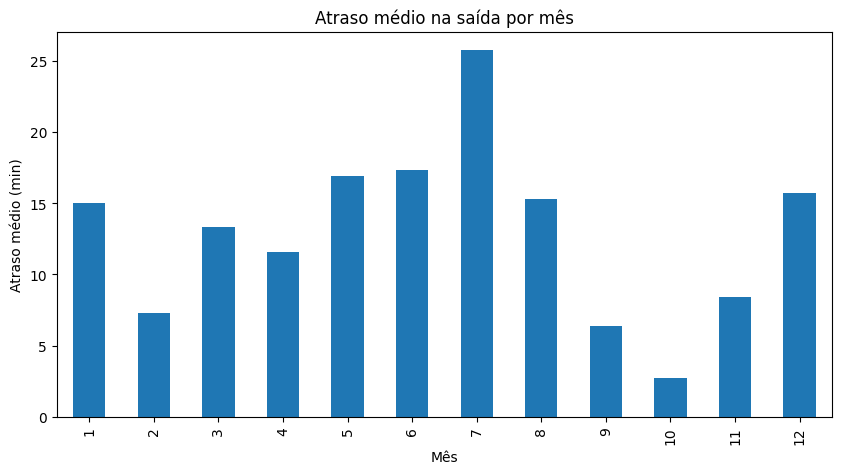

In [76]:
atraso_mes['mean'].plot(kind='bar', figsize=(10,5))
plt.title('Atraso médio na saída por mês')
plt.xlabel('Mês')
plt.ylabel('Atraso médio (min)')
plt.show()

## Atraso médio por hora prevista de saída

Nesta etapa, analisei como o atraso médio varia de acordo com a hora prevista de decolagem.

In [77]:
df['hora_saida_prevista'] = (df['crs_dep_time'] // 100).astype(int)

atraso_hora = df.groupby('hora_saida_prevista')['dep_delay'].agg(['count', 'mean', 'median']).sort_index()

atraso_hora

,count,mean,median
hora_saida_prevista,,,
0,13,10.62,12.00
1,7,3.57,-2.00
2,2,0.00,0.00
3,3,-12.67,-18.00
4,1,51.00,51.00
5,279,5.51,-4.00
6,683,8.61,-4.00
7,694,10.01,-3.00
8,671,4.59,-3.00


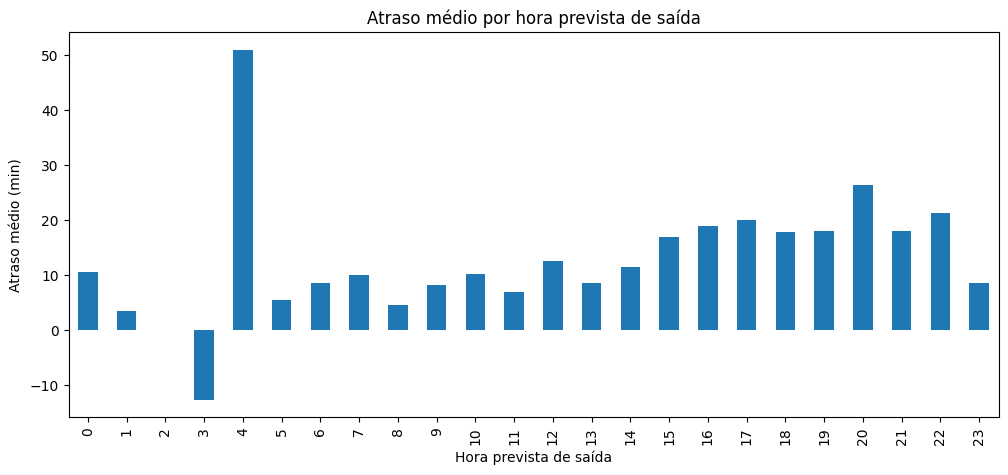

In [78]:
atraso_hora['mean'].plot(kind='bar', figsize=(12,5))
plt.title('Atraso médio por hora prevista de saída')
plt.xlabel('Hora prevista de saída')
plt.ylabel('Atraso médio (min)')
plt.show()

## Criação da variável-alvo

Aqui nessa parte, eu criei a variável `atraso_15min`, que indica se o voo teve atraso superior a 15 minutos na saída.

In [79]:
df_modelo = df.copy()

df_modelo = df_modelo.dropna(subset=['dep_delay'])

df_modelo['atraso_15min'] = (df_modelo['dep_delay'] > 15).astype(int)

df_modelo['atraso_15min'].value_counts(normalize=True) * 100

,proportion
atraso_15min,
0,79.68
1,20.32


## Preparação dos dados para modelagem

Nesta etapa, selecionei as variáveis disponíveis antes da decolagem e transformamos variáveis categóricas em colunas numéricas com one-hot encoding.

In [80]:
colunas_modelo = [
    'month',
    'day_of_month',
    'day_of_week',
    'op_unique_carrier',
    'origin',
    'dest',
    'crs_dep_time',
    'crs_arr_time',
    'distance',
    'atraso_15min'
]

df_modelo = df_modelo[colunas_modelo].copy()

df_modelo.head()

,month,day_of_month,day_of_week,op_unique_carrier,origin,dest,crs_dep_time,crs_arr_time,distance,atraso_15min
0,4,18,4,MQ,DFW,RAP,1018,1149,835.00,0
1,1,1,1,AA,CLT,PHX,1637,1923,1773.00,0
2,12,12,4,9E,CHA,ATL,1000,1059,106.00,0
3,4,8,1,WN,OMA,LAS,1330,1430,1099.00,0
4,2,16,5,WN,BWI,MYR,1340,1510,399.00,0


In [81]:
X = df_modelo.drop('atraso_15min', axis=1)
y = df_modelo['atraso_15min']

X = pd.get_dummies(
    X,
    columns=['op_unique_carrier', 'origin', 'dest'],
    drop_first=True
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X.shape

(9884, 589)

## Regressão Logística

Como a variável alvo está desbalanceada, eu utilizei uma Regressão Logística com balanceamento de classes para avaliar a capacidade do modelo em identificar voos com atraso superior a 15 minutos.

In [82]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.85      0.60      0.70      1575
           1       0.27      0.57      0.37       402

    accuracy                           0.60      1977
   macro avg       0.56      0.59      0.54      1977
weighted avg       0.73      0.60      0.64      1977



## Random Forest

Também testei um modelo de Random Forest para comparar o desempenho com a Regressão Logística e avaliar sua capacidade de identificar voos com atraso superior a 15 minutos.

In [83]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.80      0.99      0.88      1575
           1       0.35      0.03      0.06       402

    accuracy                           0.79      1977
   macro avg       0.58      0.51      0.47      1977
weighted avg       0.71      0.79      0.71      1977



## XGBoost

Por fim, testei o modelo XGBoost, que costuma ter bom desempenho em problemas tabulares e foi utilizado como principal modelo do projeto.

In [84]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=4,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.87      0.65      0.74      1575
           1       0.31      0.62      0.41       402

    accuracy                           0.64      1977
   macro avg       0.59      0.64      0.58      1977
weighted avg       0.76      0.64      0.68      1977



## Matriz de confusão do XGBoost

Nesta etapa, analisei os acertos e erros do modelo XGBoost para entender melhor sua capacidade de identificar voos com atraso superior a 15 minutos.

In [85]:
confusion_matrix(y_test, y_pred_xgb)

array([[1021,  554],
       [ 152,  250]])

In [86]:
import pandas as pd

matriz_xgb = pd.DataFrame(
    confusion_matrix(y_test, y_pred_xgb),
    index=['Real 0 - Sem atraso relevante', 'Real 1 - Atraso > 15 min'],
    columns=['Previsto 0 - Sem atraso relevante', 'Previsto 1 - Atraso > 15 min']
)

matriz_xgb

,Previsto 0 - Sem atraso relevante,Previsto 1 - Atraso > 15 min
Real 0 - Sem atraso relevante,1021,554
Real 1 - Atraso > 15 min,152,250


## Ajuste de limiar de decisão

Nesta etapa, testei diferentes limiares de decisão para o XGBoost, avaliando o equilíbrio entre recall, precision e acurácia na identificação de voos com atraso superior a 15 minutos.

In [87]:
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

limiares = [0.50, 0.40, 0.35]

for limiar in limiares:
    y_pred_limiar = (y_proba_xgb >= limiar).astype(int)

    print(f'\nLimiar: {limiar}')
    print(classification_report(y_test, y_pred_limiar))


Limiar: 0.5
              precision    recall  f1-score   support

           0       0.87      0.65      0.74      1575
           1       0.31      0.62      0.41       402

    accuracy                           0.64      1977
   macro avg       0.59      0.64      0.58      1977
weighted avg       0.76      0.64      0.68      1977


Limiar: 0.4
              precision    recall  f1-score   support

           0       0.90      0.42      0.58      1575
           1       0.26      0.81      0.40       402

    accuracy                           0.50      1977
   macro avg       0.58      0.62      0.49      1977
weighted avg       0.77      0.50      0.54      1977


Limiar: 0.35
              precision    recall  f1-score   support

           0       0.89      0.29      0.44      1575
           1       0.24      0.87      0.37       402

    accuracy                           0.41      1977
   macro avg       0.57      0.58      0.41      1977
weighted avg       0.76      0.41 

In [88]:
comparacao_limiares = pd.DataFrame({
    'limiar': [0.50, 0.40, 0.35],
    'recall_classe_1': [0.62, 0.81, 0.87],
    'precision_classe_1': [0.31, 0.26, 0.24],
    'acuracia': [0.64, 0.50, 0.41],
    'leitura': [
        'Melhor equilíbrio geral',
        'Mais sensível para detectar atrasos',
        'Recall alto, mas muitos falsos positivos'
    ]
})

comparacao_limiares

,limiar,recall_classe_1,precision_classe_1,acuracia,leitura
0,0.50,0.62,0.31,0.64,Melhor equilíbrio geral
1,0.40,0.81,0.26,0.50,Mais sensível para detectar atrasos
2,0.35,0.87,0.24,0.41,"Recall alto, mas muitos falsos positivos"


## Curva ROC e AUC

Nesta etapa, avaliei a capacidade do XGBoost de separar voos com e sem atraso relevante, utilizando a curva ROC e a métrica AUC.

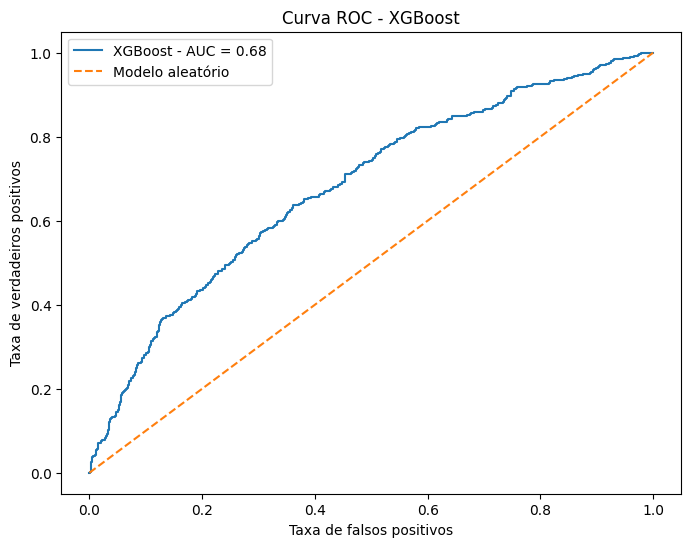

AUC: 0.6804722419647793


In [89]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba_xgb)
auc = roc_auc_score(y_test, y_proba_xgb)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'XGBoost - AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', label='Modelo aleatório')
plt.title('Curva ROC - XGBoost')
plt.xlabel('Taxa de falsos positivos')
plt.ylabel('Taxa de verdadeiros positivos')
plt.legend()
plt.show()

print("AUC:", auc)

## Conclusão

Neste projeto, desenvolvi um modelo de classificação para prever se um voo teria atraso superior a 15 minutos na saída.

Durante a análise exploratória, identifiquei que a média de atraso pode ser influenciada por atrasos extremos, por isso a mediana também foi importante para interpretar melhor os dados.

Entre os modelos testados, o XGBoost apresentou o melhor desempenho para identificar voos com atraso relevante, alcançando recall de 62% na classe 1 e AUC aproximada de 0,68.

Apesar do modelo ainda apresentar falsos positivos, ele funcionou como uma boa prova de conceito para análise preditiva aplicada ao contexto de aviação.

In [90]:
resultado_modelo = X_test.copy()

resultado_modelo['real_atraso_15min'] = y_test.values
resultado_modelo['probabilidade_atraso'] = y_proba_xgb
resultado_modelo['previsao_atraso_050'] = (y_proba_xgb >= 0.50).astype(int)

resultado_modelo.to_csv('resultado_modelo_xgboost.csv', index=False)
comparacao_limiares.to_csv('comparacao_limiares_xgboost.csv', index=False)